# Customer Segmentation and Analytics  
### Second Notebook: Feature Engineering and Clustering  

This notebook continues the exploration of customer behavior and heterogeneity using the enhanced Mall Customers dataset. The focus here is on cleaning data and applying clustering techniques to uncover latent customer segments.  

**Author:** J-F Jutras  
**Date:** March 2026  
**Dataset:** Enhanced Mall Customers Dataset (synthetic extension of the Kaggle Mall Customers dataset)  

## 2.1-Data Loading

In [1]:
import kagglehub
import pandas as pd
import os

#Download latest version
path = kagglehub.dataset_download("vikasjigupta786/customer-analytics-practice-dataset")

#Define dataset path
dataset_dir = "/kaggle/input/customer-analytics-practice-dataset"
csv_path = os.path.join(dataset_dir, "Mall_Customers_Enhanced.csv")

#Load full dataset
df = pd.read_csv(csv_path)

#Clone the public GitHub repository "jfj-utils" into the current Kaggle working directory.
#This downloads all files and folders from the repo so they can be used in the notebook.
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

#Add the cloned repository to the Python path so Python can import modules from it
import sys
sys.path.append("/kaggle/working/jfj-utils")

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (280/280), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 3527 (delta 224), reused 96 (delta 96), pack-reused 3247 (from 4)
Receiving objects: 100% (3527/3527), 1.18 MiB | 20.52 MiB/s, done.
Resolving deltas: 100% (2322/2322), done.


## 2.2-Data Cleaning and Transformation

### Handling Outliers

In [2]:
from data_preprocessing.outliers import detect_outliers_iqr

#Define numerical columns to check for outliers using the IQR method
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Estimated Savings (k$)',
               'Credit Score', 'Loyalty Years']

detect_outliers_iqr(df, numeric_cols)

{'Age': 0,
 'Annual Income (k$)': 2,
 'Spending Score (1-100)': 0,
 'Estimated Savings (k$)': 26,
 'Credit Score': 20,
 'Loyalty Years': 0,
 'Total_outliers': 48}

Outliers were detected using the IQR method. Although several extreme values were identified in Estimated Savings and Credit Score, they were intentionally retained because they likely represent meaningful high-value customer profiles rather than data errors. In customer segmentation tasks, such extreme observations often correspond to valuable niche segments (e.g., high-net-worth individuals) and therefore provide important signals for clustering algorithms.

### Categorical Encoding

Due to the exploratory nature of this analysis and the limited dataset size, preprocessing steps are applied sequentially rather than through a fully automated pipeline in order to keep the workflow transparent and easy to interpret.

In [3]:
from data_preprocessing.encoding import one_hot_encode_columns

categorical_cols = ['Gender', 'Preferred Category']

#Drop non-feature columns
df_model = df.drop(columns = ["CustomerID", "Age Group"])

df_model = one_hot_encode_columns(df_model, categorical_cols, drop_first = True)

One-hot encoding successfully applied to 2 columns on 1 dataset(s).


### Feature Scaling

In [4]:
from data_preprocessing.scaling import standard_scaler
X_scaled, scaler = standard_scaler(df_model)

--- StandardScaler Summary ---
Scaled: 6 features | Zero mean/Unit variance achieved
-----------------------------------


### Premodeling Check

In [5]:
#Initial premodeling check
from eda.premodeling_check import premodeling_clustering_check
print(premodeling_clustering_check(X_scaled))

#Missing values
No missing values detected.

#Feature types
All features are numeric (Optimal for distance calculations).

#Scale & Magnitude check
Feature scales appear relatively consistent.

#Outliers
Outliers can distort cluster centroids (Total: 48):
  1. Estimated Savings (k$): 26 points
  2. Credit Score: 20 points
  3. Annual Income (k$): 2 points

#Feature Redundancy (|r| ≥ 0.80)
Highly correlated features detected (May bias distance metrics):
  1. Annual Income (k$) ↔ Estimated Savings (k$): 0.813

#Final assessment
Data is ready for clustering, but review the issues above. Clustering is highly sensitive to Scaling, Outliers, and Redundant Features.


A strong correlation (r ≈ 0.81) was observed between Annual Income and Estimated Savings, indicating that both variables capture a similar financial dimension. To reduce feature redundancy and avoid overweighting wealth-related information in the distance metric, Estimated Savings was removed prior to clustering.

In [6]:
#Drop redundant feature
df_model = df_model.drop(columns=["Estimated Savings (k$)"])

#Rescale features
X_scaled, scaler = standard_scaler(df_model)

--- StandardScaler Summary ---
Scaled: 5 features | Zero mean/Unit variance achieved
-----------------------------------


In [7]:
#Final premodeling check
from eda.premodeling_check import premodeling_clustering_check
print(premodeling_clustering_check(X_scaled))

#Missing values
No missing values detected.

#Feature types
All features are numeric (Optimal for distance calculations).

#Scale & Magnitude check
Feature scales appear relatively consistent.

#Outliers
Outliers can distort cluster centroids (Total: 22):
  1. Credit Score: 20 points
  2. Annual Income (k$): 2 points

#Feature Redundancy (|r| ≥ 0.80)
No redundant features detected.

#Final assessment
Data is ready for clustering, but review the issues above. Clustering is highly sensitive to Scaling, Outliers, and Redundant Features.


## 2.3-Clustering

In [8]:
#Define predictors
predictors = df_model.columns.tolist()

#Select the best clustering model
from modeling.clustering_models import compare_clustering_models

for k in range(2,8):
    print(f"\n========== Testing k = {k} ==========")
    compare_clustering_models(X_scaled, predictors, k=k)


========== Testing k = 2 ==========
Starting Clustering Comparison | Predictors: 9
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


,Model,Clusters,Silhouette
0,Agglomerative,2,0.3197
4,KMeans,2,0.3042
1,BIRCH,2,0.2587
3,GMM,2,0.2509
2,DBSCAN,4,-0.2163



========== Testing k = 3 ==========
Starting Clustering Comparison | Predictors: 9
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


,Model,Clusters,Silhouette
3,GMM,3,0.2884
4,KMeans,3,0.2804
1,BIRCH,3,0.2593
0,Agglomerative,3,0.2547
2,DBSCAN,4,-0.2163



========== Testing k = 4 ==========
Starting Clustering Comparison | Predictors: 9
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


...

,Model,Clusters,Silhouette
4,KMeans,5,0.3672
0,Agglomerative,5,0.3452
1,BIRCH,5,0.3388
3,GMM,5,0.3066
2,DBSCAN,4,-0.2163



========== Testing k = 6 ==========
Starting Clustering Comparison | Predictors: 9
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


,Model,Clusters,Silhouette
1,BIRCH,6,0.3672
4,KMeans,6,0.3657
0,Agglomerative,6,0.3646
3,GMM,6,0.3080
2,DBSCAN,4,-0.2163



========== Testing k = 7 ==========
Starting Clustering Comparison | Predictors: 9
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


,Model,Clusters,Silhouette
1,BIRCH,7,0.3590
4,KMeans,7,0.3573
0,Agglomerative,7,0.3414
3,GMM,7,0.2678
2,DBSCAN,4,-0.2163


Multiple clustering algorithms were evaluated across several cluster configurations (k = 2–7) using silhouette scores to assess cluster cohesion and separation. The best overall performance was achieved by the K-Means clustering model with five clusters, which provided the strongest balance between interpretability and segmentation quality (silhouette ≈ 0.37). This configuration was therefore selected as the champion model for the final customer segmentation analysis.

In [9]:
from modeling.clustering_models import kmeans_clustering
kmeans_model = kmeans_clustering(X_scaled, predictors, k = 5)
labels = kmeans_model.predict(X_scaled[predictors])

--- KMeans Clustering Summary ---
Clusters: 5 | Optimized: False
-----------------------------------



--- Clustering Performance Check ---
Model                     : KMeans (k=5)
Number of Clusters         : 5
Silhouette Score           : 0.3672  (Goal: -> 1.0)
Calinski-Harabasz Index    : 98.52 (Goal: High)
Davies-Bouldin Index       : 1.0307  (Goal: -> 0.0)
---------------------------------------------
Status: ACCEPTABLE. Moderate structure detected; some overlap likely.
---------------------------------------------


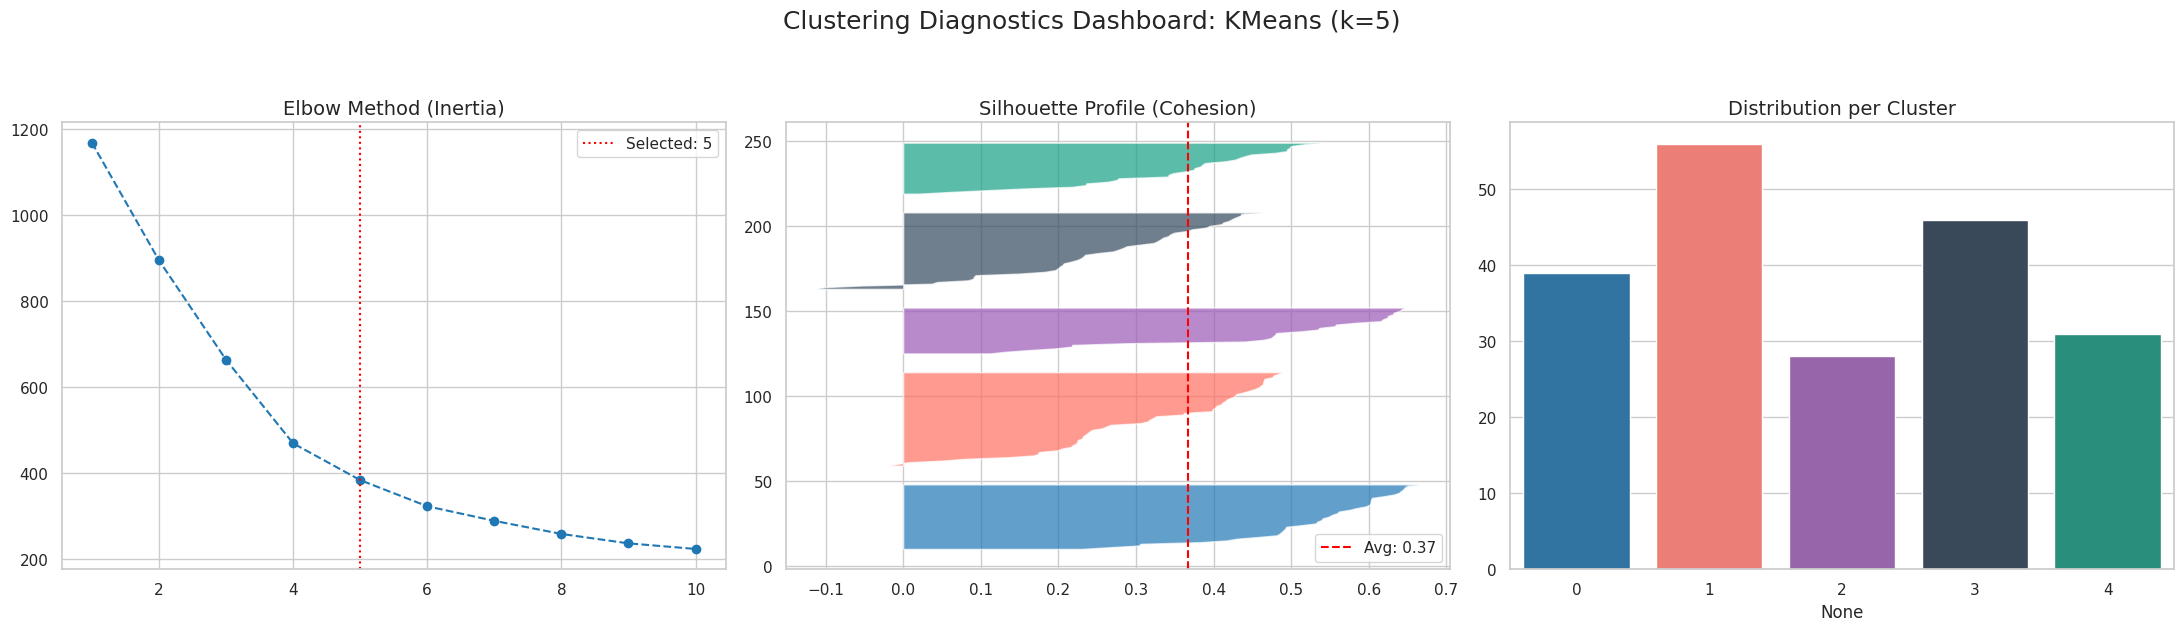

{'silhouette': np.float64(0.3671605333652914),
 'calinski_harabasz': np.float64(98.5228667230143),
 'davies_bouldin': np.float64(1.0307430790940229),
 'n_clusters': 5}

In [10]:
from visualization.explore_clusters import plot_cluster_diagnostics
plot_cluster_diagnostics(X_scaled[predictors],labels, "KMeans (k=5)")

KMeans identified 5 clusters within the customer data. Cluster cohesion and separation are moderate (Silhouette ≈ 0.37), indicating distinct segments with some overlap. The Calinski-Harabasz and Davies-Bouldin indices confirm a reasonable segmentation, capturing the diversity of customer behaviors and profiles.

In [11]:
from modeling.model_stability import check_clustering_model_stability
check_clustering_model_stability(kmeans_model, X_scaled, predictors)


--- Clustering Algorithmic Stability Check ---
Model Class              : KMeans
Seeds Evaluated           : [0, 21, 42, 84]
Subsample Fraction        : 0.8
--------------------------------------------------
Random Initialization Stability (ARI):
  ARI(seed 0 vs 21) = 0.974
  ARI(seed 0 vs 42) = 0.949
  ARI(seed 0 vs 84) = 1.000
  Mean ARI (seeds)        = 0.974
--------------------------------------------------
Subsampling Stability (ARI):
  ARI(subsample run 1) = 1.000
  ARI(subsample run 2) = 0.977
  ARI(subsample run 3) = 0.553
  Mean ARI (subsampling)  = 0.843
--------------------------------------------------
Status: HIGHLY STABLE. Cluster structure is robust.
--------------------------------------------------


{'ari_seeds_mean': np.float64(0.9743411543339903),
 'ari_subsampling_mean': np.float64(0.8434124791952039),
 'ari_overall_mean': np.float64(0.9088768167645971),
 'ari_seeds': [0.973860350292941, 0.9491631127090294, 1.0],
 'ari_subsampling': [1.0, 0.9768245630544695, 0.5534128745311423]}

The KMeans clustering model demonstrates high algorithmic stability. Random initialization across different seeds shows almost perfect consistency (mean ARI ≈ 0.97), and subsampling tests indicate that the cluster structure remains largely robust (mean ARI ≈ 0.84). Overall, the clusters are well-defined and reliable for downstream analysis.

## 2.4-Cluster Interpretation

In [12]:
#Examine cluster sizes
df_clusters = df_model.copy()
df_clusters['Cluster'] = labels
print(df_clusters['Cluster'].value_counts())

Cluster
1    56
3    46
0    39
4    31
2    28
Name: count, dtype: int64


In [13]:
#Compare feature means
cluster_summary = df_clusters.groupby('Cluster').mean()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Credit Score,Loyalty Years,Gender_Male,Preferred Category_Electronics,Preferred Category_Fashion,Preferred Category_Luxury
Cluster,,,,,,,,,
0,32.692308,86.538462,82.128205,830.820513,6.871795,0.461538,0.000000,0.102564,0.897436
1,55.625000,49.410714,43.714286,758.803571,7.285714,0.464286,0.803571,0.000000,0.000000
2,26.428571,25.857143,72.000000,410.500000,5.892857,0.428571,0.000000,0.035714,0.678571
3,27.195652,56.369565,36.239130,782.543478,4.065217,0.369565,0.065217,0.760870,0.000000
4,44.806452,85.580645,22.774194,850.000000,5.096774,0.483871,0.967742,0.032258,0.000000


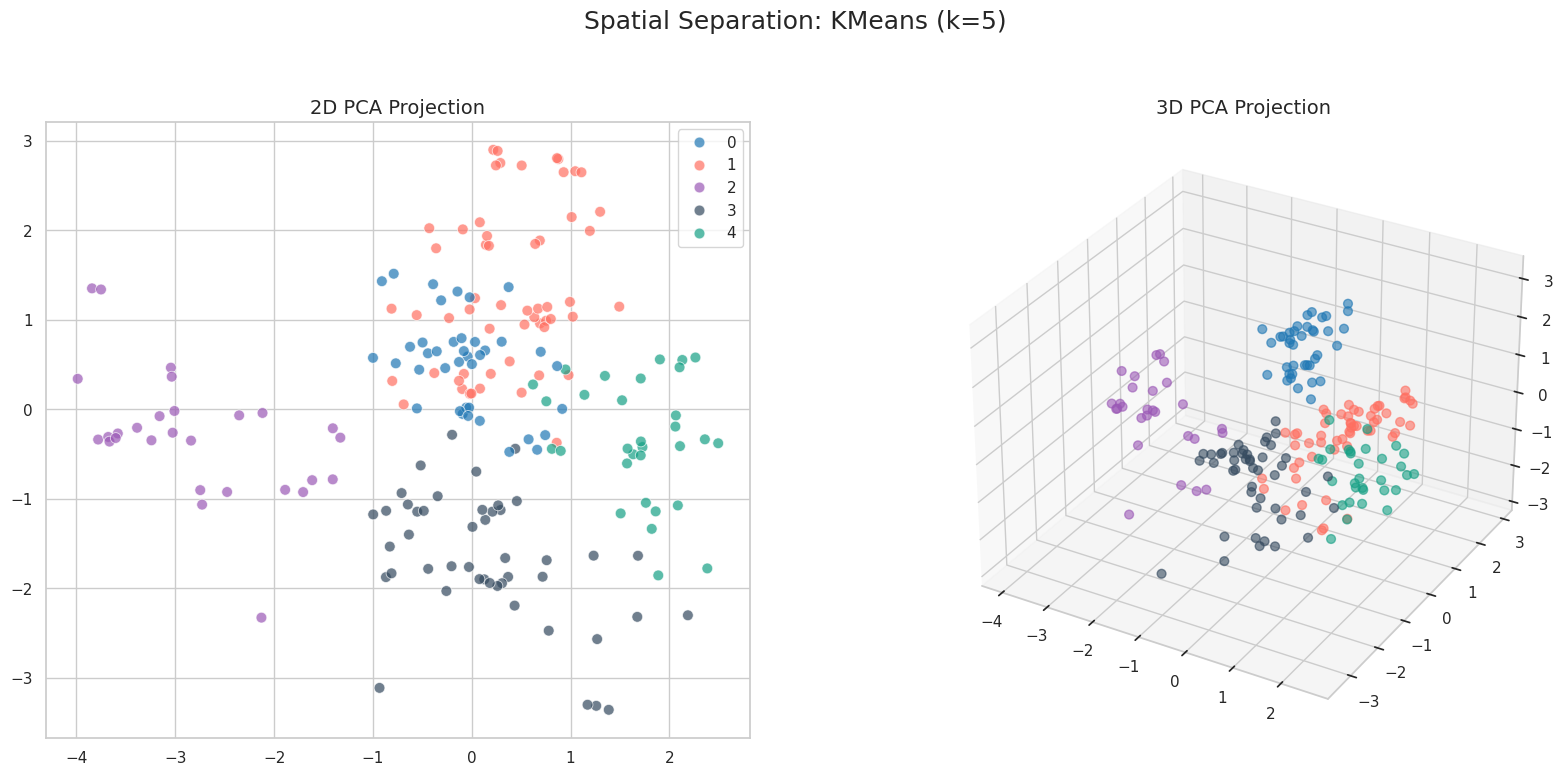

In [14]:
#2D + 3D PCA projections of clusters
from visualization.explore_clusters import plot_cluster_projections
plot_cluster_projections(X_scaled[predictors], labels, model_name="KMeans (k=5)")

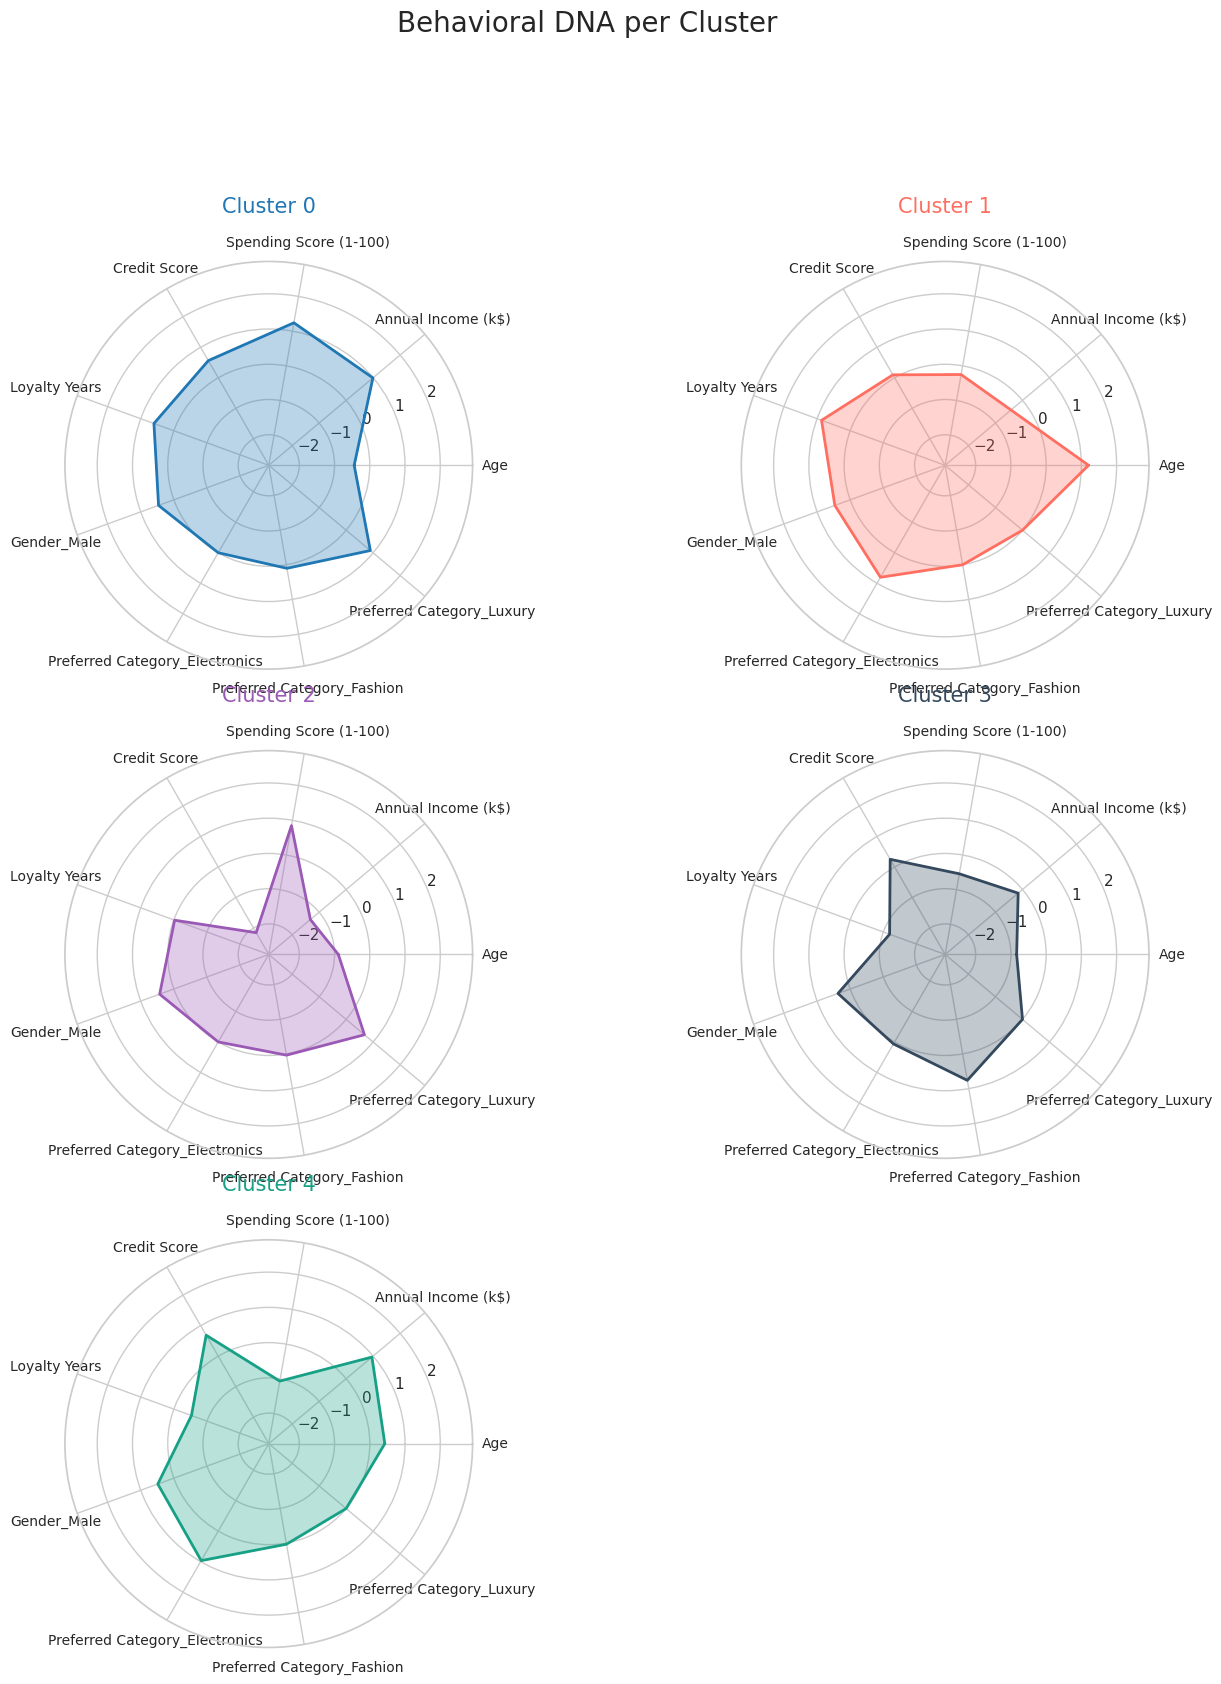

In [15]:
#Radar charts to profile each cluster
from visualization.explore_clusters import plot_cluster_radar_charts
plot_cluster_radar_charts(X_scaled[predictors], labels, feature_names=predictors)

| Cluster ID | Cluster Name                     | Age (avg) | Annual Income (k$) | Spending Score (1-100) | Credit Score | Loyalty Years | Gender_Male | Electronics | Fashion | Luxury | Profile Summary |
|------------|---------------------------------|-----------|-------------------|------------------------|--------------|---------------|-------------|------------|--------|-------|----------------|
| 0          | Young Luxury Shoppers           | 32.7      | 86.5              | 82.1                   | 830.8        | 6.87          | 46%         | 0%         | 10%    | 90%   | Young customers with high income, heavy luxury spenders. |
| 1          | Older Moderate Spenders         | 55.6      | 49.4              | 43.7                   | 758.8        | 7.29          | 46%         | 80%        | 0%     | 0%    | Older customers with mid-range income, moderate spending. |
| 2          | Young Budget-Conscious          | 26.4      | 25.9              | 72.0                   | 410.5        | 5.89          | 43%         | 0%         | 3.6%   | 68%   | Very young, low-income customers, relatively high spenders, mostly in luxury/fashion. |
| 3          | Young Fashion Enthusiasts       | 27.2      | 56.4              | 36.2                   | 782.5        | 4.06          | 37%         | 6.5%       | 76%    | 0%    | Young, mid-income customers, low spenders, strong preference for fashion. |
| 4          | Mature High-Income Electronics  | 44.8      | 85.6              | 22.8                   | 850.0        | 5.09          | 48%         | 97%        | 3%     | 0%    | Older, very high-income customers, low spending, strong interest in electronics. |

## 2.5-Summary - Notebook 2

| Step | Key Actions | Main Insights & Results |
|------|-------------|------------------------|
| 1 | Data Cleaning & Transformation | Outlier detection (IQR), redundant feature removal (Estimated Savings), and one-hot encoding for categorical columns. X_scaled created with 5 numeric features; no missing values; outliers retained for segmentation relevance. |
| 2 | Feature Scaling & Premodeling Check | Standard scaling applied; premodeling checks for scale consistency, redundancy, and outliers. Data ready for clustering; moderate feature correlations identified and addressed. |
| 3 | Clustering Comparison | Multiple clustering algorithms tested (KMeans, Agglomerative, BIRCH, GMM, DBSCAN, KMedoids) across k = 2–7 using silhouette scores. KMeans with k=5 achieved the best balance (Silhouette ≈ 0.37) and selected as champion model. |
| 4 | Cluster Diagnostics | Internal validity metrics computed (Silhouette, Calinski-Harabasz, Davies-Bouldin) and visual dashboard generated. Moderate cluster cohesion and separation; clusters capture meaningful behavioral patterns. |
| 5 | Stability Assessment | Algorithmic stability checked via random seed variations and subsampling (ARI metrics). KMeans clusters are highly stable (Mean ARI seeds ≈ 0.97; subsampling ≈ 0.84); reliable for downstream analysis. |
| 6 | Cluster Projection & Visualization | 2D/3D PCA projections and radar charts plotted for feature-wise cluster interpretation. Clear spatial separation in PCA; radar charts highlight cluster-specific behavioral “DNA”. |
| 7 | Cluster Interpretation | Cluster sizes and feature means summarized; descriptive labels assigned. 5 distinct customer segments identified: Young Luxury Shoppers, Older Moderate Spenders, Young Budget-Conscious, Young Fashion Enthusiasts, Mature High-Income Electronics. |